# FNN Classificator

The code below explores the application of a **Feedforward Neural Network (FNN)** to the problem of credit default prediction. Three relatively shallow FNN architectures were tested and their performance was compared with the machine learning models evaluated previously. The models were built using the TensorFlow library

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn import linear_model, model_selection
from sklearn.preprocessing import StandardScaler

In [6]:
train = pd.read_csv('train_processed.csv')
validation = pd.read_csv('validation_processed.csv')
test = pd.read_csv('test_processed.csv')
train.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [7]:
# Features and Label
# for train 
y_train = train['loan_status']
X_train = train.iloc[:, 1:]

# for validation
y_val = validation['loan_status']
X_val = validation.iloc[:, 1:]

# for test
y_test = test['loan_status']
X_test = test.iloc[:, 1:]

## Data Normalisation

Neural networks are sensitive to feature scaling. Therefore, the numerical features are standardised using StandardScaler to improve training stability and facilitate model convergence

In [8]:
# The list of the numerical features
columns_num = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
           'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delta_issue_earliest']

# The list of the encoded categorical features
columns_cat = ['pub_rec', 'mort_acc', 'pub_rec_bankruptcies', 'term__ 36 months', 'term__ 60 months',
              'emp__10+ years', 'emp__3-5 years', 'emp__6-9 years', 'emp__<=2 years', 
              'home__MORTGAGE', 'home__OTHERS','home__OWN', 'home__RENT', 
               'verif__Not Verified', 'verif__Source Verified', 'verif__Verified',
              'purpose__consumer_needs', 'purpose__credit_card','purpose__debt_consolidation',
              'purpose__home_improvement', 'purpose__other', 'list__f', 'list__w']

In [9]:
# Scaling the numerical featires to unit variance
std_scaler = StandardScaler()

# Fit to the training data and transform
X_train_scaled = std_scaler.fit_transform(X_train[columns_num])

# Transforming the validation and test data on the scale of the training data
X_val_scaled = std_scaler.transform(X_val[columns_num])
X_test_scaled = std_scaler.transform(X_test[columns_num])

In [10]:
# Convert the arrays to the Pandas dataframes
train_num_scaled = pd.DataFrame(X_train_scaled, columns = columns_num)
val_num_scaled = pd.DataFrame(X_val_scaled, columns = columns_num)
test_num_scaled = pd.DataFrame(X_test_scaled, columns = columns_num)

train_num_scaled.head(2)

,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,delta_issue_earliest
0,1.243952,1.198444,1.653493,-1.389759,-0.499299,0.810783,-0.198462,-0.406161,-1.015377
1,-1.135495,-0.028264,-0.811220,-1.409454,0.465383,-0.381006,-0.357267,1.021899,0.976272


In [11]:
# Categorical features
train_cat = X_train[columns_cat]
val_cat = X_val[columns_cat]
test_cat = X_test[columns_cat]

train_cat.head(2)

,pub_rec,mort_acc,pub_rec_bankruptcies,term__ 36 months,term__ 60 months,emp__10+ years,emp__3-5 years,emp__6-9 years,emp__<=2 years,home__MORTGAGE,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,1,0,0,1,0,0,1,0,1,...,0,0,1,0,0,1,0,0,1,0
1,1,0,1,1,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [12]:
# Concatenation of the features into the datasets ready for training
X_tr_scaled = pd.concat([train_num_scaled, train_cat], axis=1)
X_val_scaled = pd.concat([val_num_scaled, val_cat], axis=1)
X_test_scaled = pd.concat([test_num_scaled, test_cat], axis=1)

X_tr_scaled.head(2)

,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,delta_issue_earliest,pub_rec,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,1.243952,1.198444,1.653493,-1.389759,-0.499299,0.810783,-0.198462,-0.406161,-1.015377,0,...,0,0,1,0,0,1,0,0,1,0
1,-1.135495,-0.028264,-0.811220,-1.409454,0.465383,-0.381006,-0.357267,1.021899,0.976272,1,...,1,0,0,1,0,0,0,0,0,1


## Models Training

Since this is a tabular binary classification problem with ~238K rows and 32 input features I use a relatively shallow Multilayer Perceptron (MLP). The hidden layers use ReLU activation function, the output layer uses a sigmoid activation function to predict the probability of default. The model is trained by minimising the binary cross-entropy loss, which is the standard loss function for binary classification.

Three network architectures are evaluated:

1. A benchmark 2-hidden-layer architecture with 64 and 32 neurons
2. A 2-hidden-layer architecture with an increased number of neurons (128 and 64) to assess whether a higher model capacity improves predictive performance
3. A 3-hidden-layer architecture to evaluate whether additional network depth captures more complex non-linear relationships in the data

The models are trained using the Adam (Adaptive Moment Estimation) optimiser. A relatively small batch size of 500 is used, as the available computational resources allow it and smaller batches may improve generalisation by introducing greater stochasticity during optimisation. 
with the relatively small batches (500) as my compute can afford it and it gives you a bit better generalisation. The regularisation is implemented through early stopping.

Since I test 3 networks,  models I wrapped the threshold search and model evaluation into reusable functions:

In [13]:
def validation_metrics(y_train, y_train_pred, y_val, y_val_pred):
    """Prints the key business metrics"""
    print('Train Confusion Matrix: \n', metrics.confusion_matrix(y_train, y_train_pred), '\n')
    print('Train Recall:', round(metrics.recall_score(y_train, y_train_pred), 3))
    print('Train Precision:', round(metrics.precision_score(y_train, y_train_pred), 3), '\n')
    print('Validation Confusion Matrix: \n', metrics.confusion_matrix(y_val, y_val_pred), '\n')
    print('Validation Recall:', round(metrics.recall_score(y_val, y_val_pred), 3))
    print('Validation Precision:', round(metrics.precision_score(y_val, y_val_pred), 3), '\n')

    print('F1 score train:', round(metrics.f1_score(y_train, y_train_pred), 3))
    print('F1 score validation:', round(metrics.f1_score(y_val, y_val_pred), 3))

In [14]:
def threshold_search(y_val_score):
    """Defines the best classification threshold"""
    thresholds = np.arange(0.01, 1, 0.01)

    best_f1 = 0
    best_threshold = 0

    for t in thresholds:
        pred = (y_val_score >= t).astype(int)
    
        f1 = metrics.f1_score(y_val, pred)
    
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    print('The best Classification Threshold:', round(best_threshold, 3))
    print('The best F1 score:', round(best_f1, 3))
    
    return best_threshold

In [15]:
def plot_the_loss_curve(loss_train, loss_val):
    """Plot a curve of loss vs. epoch."""

    plt.figure(figsize=(10, 8))
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')

    plt.plot(loss_train, label='Training Loss')
    plt.plot(loss_val, label='Validation Loss')
    plt.legend()
    plt.show()

### Benchmark Model

In [16]:
# Benchmark FNN model with two hidden layers (64 and 32 neurons) using ReLU activation
dnn_benchmark = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(32,  activation='relu', kernel_initializer='he_normal'),
    # The output layer uses sigmoid activation to predict the probability of default.
    tf.keras.layers.Dense(1, activation='sigmoid') 
], name='fnn_binary_classifier')

dnn_benchmark.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',  metrics=[tf.keras.metrics.AUC(name='auc')])

history_b = dnn_benchmark.fit(X_tr_scaled, y_train, validation_data=(X_val_scaled, y_val),
        epochs=100, batch_size=500, verbose=0,
        # Early stopping is used to regularise the model.
        # Validation AUC is monitored instead of F1, as F1 is not available as a built-in Keras metric. 
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)])

loss_train_b = history_b.history['loss']
loss_val_b = history_b.history['val_loss']

In [18]:
# Predict probabilities for the training and validation sets
y_train_prob_dnn_b = dnn_benchmark.predict(X_tr_scaled, verbose=0).ravel()
y_val_prob_dnn_b = dnn_benchmark.predict(X_val_scaled, verbose=0).ravel()

# Identify the optimal classification threshold on the validation set
best_threshold_dnn_b = threshold_search(y_val_prob_dnn_b)

# Convert predicted probabilities into class labels using the optimal classification threshold
y_train_pred_dnn_b = (y_train_prob_dnn_b >= best_threshold_dnn_b).astype(int)
y_val_pred_dnn_b = (y_val_prob_dnn_b >= best_threshold_dnn_b).astype(int)

The best Classification Threshold: 0.21
The best F1 score: 0.427


The optimal classification threshold differs from that of the previously tested models because the neural network produces a different distribution of predicted probabilities. As with the other models, the threshold is selected by maximising the F1 score on the validation set

In [19]:
validation_metrics(y_train, y_train_pred_dnn_b, y_val, y_val_pred_dnn_b)

Train Confusion Matrix: 
 [[130817  60637]
 [ 16860  30228]] 

Train Recall: 0.642
Train Precision: 0.333 

Validation Confusion Matrix: 
 [[28062 12964]
 [ 3831  6259]] 

Validation Recall: 0.62
Validation Precision: 0.326 

F1 score train: 0.438
F1 score validation: 0.427


The small difference between the training (0.438) and validation (0.427) F1 scores means that the model generalises well and shows little evidence of overfitting

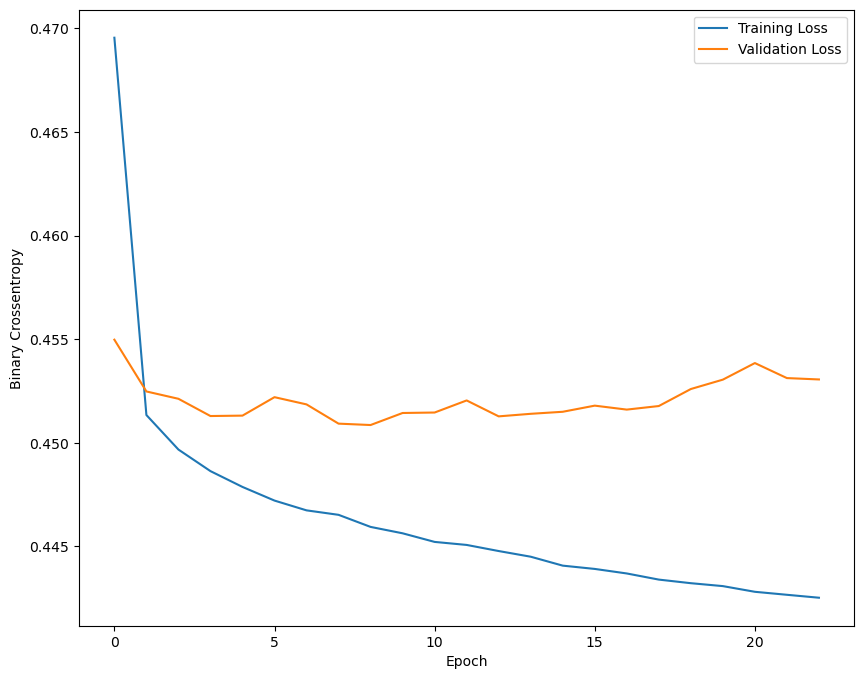

In [21]:
plot_the_loss_curve(loss_train_b, loss_val_b)

The model converges quickly during the first few epochs, with both the training and validation loss decreasing. After approximately 8 epochs, the validation loss reaches a plateau and then increases slightly, while the training loss continues to decrease. Early stopping restores the model weights corresponding to the highest validation AUC

### Model with the Increased Number of Neurons

In [22]:
# FNN model with 2 hidden layers and increased number of neurons
dnn_increased = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(64,  activation='relu', kernel_initializer='he_normal'), 
    tf.keras.layers.Dense(1, activation='sigmoid') 
], name='fnn_binary_classifier')

dnn_increased.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',  metrics=[tf.keras.metrics.AUC(name='auc')])

history_i = dnn_increased.fit(X_tr_scaled, y_train, validation_data=(X_val_scaled, y_val),
        epochs=100, batch_size=500, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)])

loss_train_i = history_i.history['loss']
loss_val_i = history_i.history['val_loss']

In [24]:
# Predict probabilities for the training and validation sets
y_train_prob_dnn_inc = dnn_increased.predict(X_tr_scaled, verbose=0).ravel()
y_val_prob_dnn_inc = dnn_increased.predict(X_val_scaled, verbose=0).ravel()

# Identify the optimal classification threshold on the validation set
best_threshold_dnn_inc = threshold_search(y_val_prob_dnn_inc)

# Convert predicted probabilities into class labels using the optimal classification threshold
y_train_pred_dnn_inc = (y_train_prob_dnn_inc >= best_threshold_dnn_inc).astype(int)
y_val_pred_dnn_inc = (y_val_prob_dnn_inc >= best_threshold_dnn_inc).astype(int)

The best Classification Threshold: 0.23
The best F1 score: 0.427


In [25]:
validation_metrics(y_train, y_train_pred_dnn_inc, y_val, y_val_pred_dnn_inc)

Train Confusion Matrix: 
 [[140078  51376]
 [ 19284  27804]] 

Train Recall: 0.59
Train Precision: 0.351 

Validation Confusion Matrix: 
 [[29940 11086]
 [ 4344  5746]] 

Validation Recall: 0.569
Validation Precision: 0.341 

F1 score train: 0.44
F1 score validation: 0.427


No difference in F1 score, but recall dropped a bit when precision increased

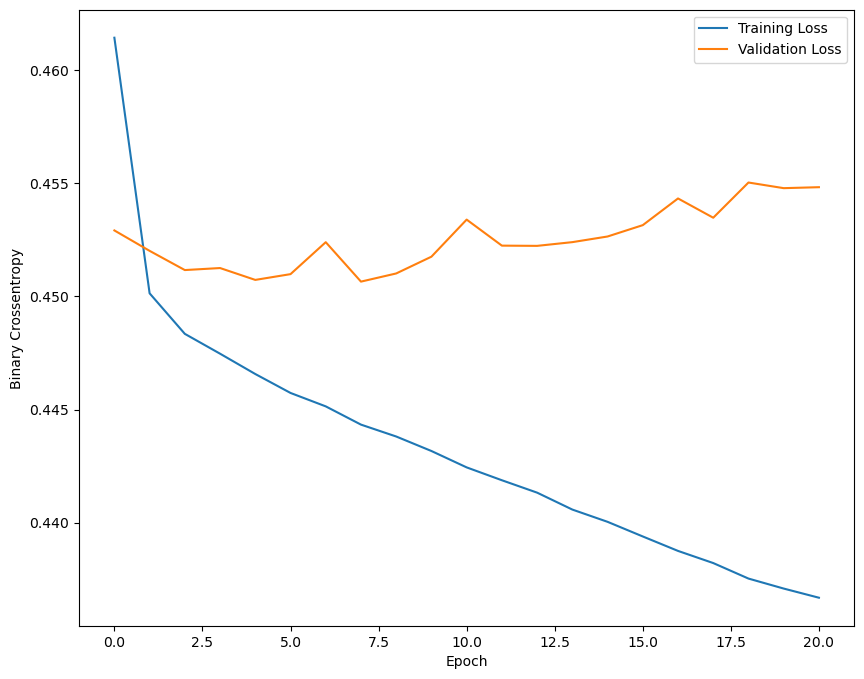

In [26]:
plot_the_loss_curve(loss_train_i, loss_val_i)

### Deeper Model

In [27]:
# FNN model with 3 hidden layers
dnn_deeper = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(64,  activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(32,  activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
], name='fnn_binary_classifier')

dnn_deeper.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',  metrics=[tf.keras.metrics.AUC(name='auc')])

history_d = dnn_deeper.fit(X_tr_scaled, y_train, validation_data=(X_val_scaled, y_val),
        epochs=100, batch_size=500, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)])

loss_train_d = history_d.history['loss']
loss_val_d = history_d.history['val_loss']

In [28]:
# Predict probabilities for the training and validation sets
y_train_prob_dnn_d = dnn_deeper.predict(X_tr_scaled, verbose=0).ravel()
y_val_prob_dnn_d = dnn_deeper.predict(X_val_scaled, verbose=0).ravel()

# Identify the optimal classification threshold on the validation set
best_threshold_dnn_d = threshold_search(y_val_prob_dnn_d)

#y predictions on the best classification threshold
y_train_pred_dnn_d = (y_train_prob_dnn_d >= best_threshold_dnn_d).astype(int)
y_val_pred_dnn_d = (y_val_prob_dnn_d >= best_threshold_dnn_d).astype(int)

The best Classification Threshold: 0.18
The best F1 score: 0.424


In [29]:
validation_metrics(y_train, y_train_pred_dnn_d, y_val, y_val_pred_dnn_d)

Train Confusion Matrix: 
 [[124698  66756]
 [ 15258  31830]] 

Train Recall: 0.676
Train Precision: 0.323 

Validation Confusion Matrix: 
 [[26663 14363]
 [ 3511  6579]] 

Validation Recall: 0.652
Validation Precision: 0.314 

F1 score train: 0.437
F1 score validation: 0.424


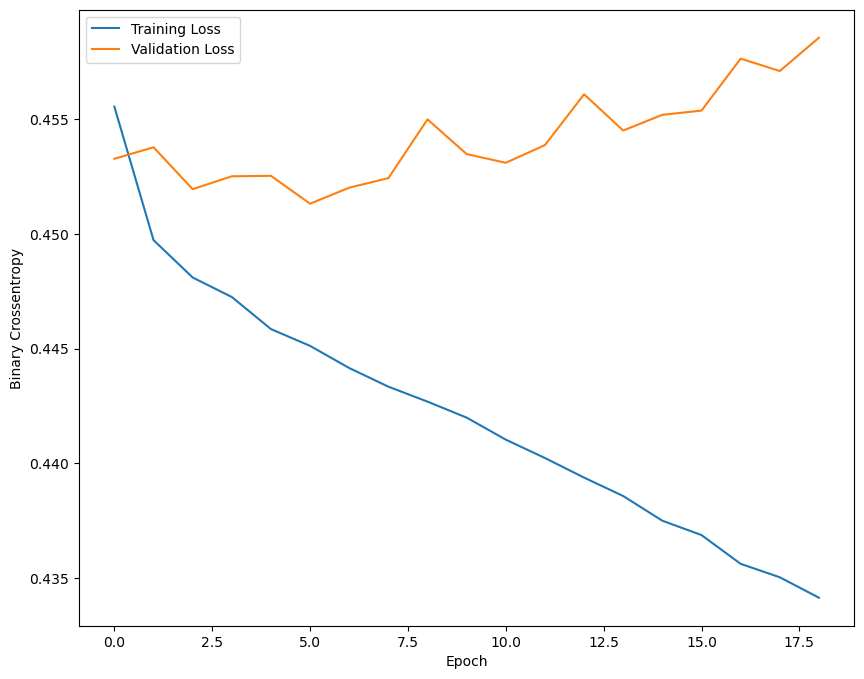

In [30]:
plot_the_loss_curve(loss_train_d, loss_val_d)

All three FNN architectures performed comparable to the Random Forest model, but slightly below that of XGBoost. 

Increasing the network depth and the number of neurons did not improve the validation F1 score. Instead, the larger architectures showed a greater degree of overfitting, as indicated by the increasing gap between the training and validation loss curves. This suggests that additional model complexity does not provide meaningful predictive gains for the current feature set. Therefore, the benchmark architecture is selected for evaluation on the test dataset

## Model Testing

In [55]:
y_test_score = dnn_benchmark.predict(X_test_scaled, verbose=0).ravel()
y_test_pred =  (y_test_score >= best_threshold_dnn_b).astype(int)

In [56]:
print('Test Confusion Matrix: \n', metrics.confusion_matrix(y_test, y_test_pred), '\n')
print('Test Recall:', round(metrics.recall_score(y_test, y_test_pred), 3))
print('Test Precision:', round(metrics.precision_score(y_test, y_test_pred), 3), '\n')
print('F1 score test:', round(metrics.f1_score(y_test, y_test_pred), 3))

Test Confusion Matrix: 
 [[27859 13168]
 [ 3766  6324]] 

Test Recall: 0.627
Test Precision: 0.324 

F1 score test: 0.428


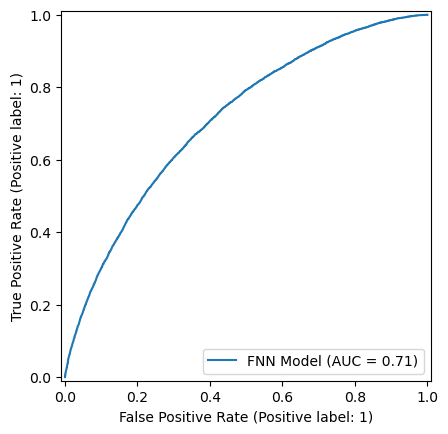

In [57]:
metrics.RocCurveDisplay.from_predictions(y_test, y_test_score, name='FNN Model')
plt.show()

## Conclusion

The benchmark FNN achieved a test F1 score of 0.428, comparable to the Random Forest model (0.426), but slightly below XGBoost (0.436), which delivered the strongest predictive performance among the models evaluated.

Increasing the complexity of the network architecture by adding more neurons or hidden layers did not improve predictive performance and resulted in a greater tendency to overfit.

Unlike Logistic Regression and tree-based models, feedforward neural networks are less transparent and do not provide directly interpretable measures of feature importance. Given their comparable predictive performance and lower interpretability, traditional machine learning models (especially XGBoost) represent a more practical choice for this credit default prediction problem

**Summary of the Test Metrics:**

| Metrics | Model Performance | 
|:-----------|:------------:|
| F1 Score   |  0.428   | 
| Precision        |  0.324 | 
| Recall|0.627|
| AUC |0.71|